# Exploratory Data Analysis: Most Streamed Spotify Songs 2024

**Dataset source:** [Kaggle - Most Streamed Spotify Songs 2024](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024)

**Author:** Gogineni Gouthami

**About the dataset:**
This dataset has streaming numbers for the top songs on Spotify's "All Time" ranking, along with how those same songs are doing on other platforms like YouTube, TikTok, Apple Music, Deezer, Pandora, Soundcloud, radio (AirPlay/SiriusXM), and Shazam.

I wanted to explore this dataset to practice my EDA skills and answer some questions I was curious about, like:

1. How trustworthy is this data, and what has to be fixed before I can rely on it?
2. Is streaming success concentrated in a small number of artists/tracks, or spread across many?
3. Out of everything in this dataset, what correlates most strongly with a song's success (streams, and `Track Score`) — and does the same thing matter across other platforms too, or does each platform reward something different?
4. Does going viral on TikTok actually translate into Spotify streams, or are TikTok virality and Spotify streaming success basically two different kinds of "popularity"?
5. Does explicit content help, hurt, or make no real difference to performance?
6. Is a song's chart position mostly just a matter of being old and having more time to accumulate streams — or can a new song break into the top ranks fast?
7. Are there tracks that are massive on one platform but nearly invisible on another — and what would explain a mismatch like that?


# Required Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

pd.set_option('display.max_columns', None)

# Loading the data

I got a `UnicodeDecodeError` when I used `pd.read_csv()` at first. After a bit of googling, I found out this usually happens when a file has special characters (like accented letters in artist/song names, e.g. "Bad Bunny" songs which have Spanish titles) and isn't saved in standard UTF-8 encoding.

The fix was to load it with `encoding='latin-1'` (also called ISO-8859-1) instead.

In [61]:
spotify_data='/kaggle/input/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024/Most Streamed Spotify Songs 2024.csv'
df = pd.read_csv(spotify_data,encoding='latin-1')
df.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92.0,"84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040",210.0,"40,975",684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92.0,"116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351",188.0,"40,778",3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92.0,"122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955",190.0,"74,333",536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",85.0,"1,096,100,899","10,629,796","7,189,811","1,078,757,968","14,603,725,994","3,351,188,582",394.0,"1,474,799","2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",88.0,"77,373,957","3,670,188","16,400",NaN,NaN,"112,763,851",182.0,"12,185",1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


# 1. Understanding and Data Cleaning

## 1.1 Basic Shape and Structure of the data

In [62]:
df.shape

(4600, 29)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTok Posts                3427 

### Insights from `df.info()`:

- There are 4,600 rows and 29 columns.
- A lot of columns that should obviously be numbers (`Spotify Streams`, `YouTube Views`, `TikTok Likes`, etc.) are showing up as `object` type. That's a sign they probably have commas in them (like `"1,234,567"`), which pandas reads as plain text instead of a number.
- `Release Date` is also text, so I'll need to convert that to an actual date.
- Non-null counts don't match the total row count (4600) for a lot of columns, so there's missing data to deal with.

## 1.2 Fixing the number columns

In [64]:
# columns that are stored as text with commas instead of actual numbers
columns_with_commas = [
    'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach',
    'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes',
    'TikTok Views', 'YouTube Playlist Reach', 'AirPlay Spins', 'SiriusXM Spins',
    'Deezer Playlist Reach', 'Pandora Streams', 'Pandora Track Stations',
    'Soundcloud Streams', 'Shazam Counts', 'All Time Rank'
]

for col in columns_with_commas:
    # remove the commas, then convert to a number
    # errors='coerce' turns anything that still can't be converted into NaN instead of crashing
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[columns_with_commas].dtypes

Spotify Streams           float64
Spotify Playlist Count    float64
Spotify Playlist Reach    float64
YouTube Views             float64
YouTube Likes             float64
TikTok Posts              float64
TikTok Likes              float64
TikTok Views              float64
YouTube Playlist Reach    float64
AirPlay Spins             float64
SiriusXM Spins            float64
Deezer Playlist Reach     float64
Pandora Streams           float64
Pandora Track Stations    float64
Soundcloud Streams        float64
Shazam Counts             float64
All Time Rank               int64
dtype: object

## 1.3 Fixing the Release Date Column

In [65]:
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year

print("Earliest release date in the dataset:", df['Release Date'].min())
print("Most recent release date in the dataset:", df['Release Date'].max())
print("Rows where the date couldn't be converted:", df['Release Date'].isnull().sum())

Earliest release date in the dataset: 1987-07-21 00:00:00
Most recent release date in the dataset: 2024-06-14 00:00:00
Rows where the date couldn't be converted: 0


## 1.4 Checking for Duplicate Rows

In [66]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Rows with a duplicate ISRC code:", df['ISRC'].duplicated().sum())

# ISRC is basically a unique ID for a recording, so if two rows share
# the same ISRC, they should genuinely be the same entry in the dataset
df[df['ISRC'].duplicated(keep=False)].sort_values('ISRC')[['Track', 'Artist', 'ISRC', 'Release Date']]

Fully duplicate rows: 2
Rows with a duplicate ISRC code: 2


,Track,Artist,ISRC,Release Date
2449,Tennessee Orange,Megan Moroney,TCAGJ2289254,2022-09-02
2450,Tennessee Orange,Megan Moroney,TCAGJ2289254,2022-09-02
3447,Dembow,Danny Ocean,USWL11700269,2017-12-08
3450,Dembow,Danny Ocean,USWL11700269,2017-12-08


In [67]:
df = df.drop_duplicates(subset='ISRC', keep='first')
print("Shape after removing exact duplicates:", df.shape)

Shape after removing exact duplicates: (4598, 30)


## 1.5 Missing Values

In [68]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percent
TIDAL Popularity,4598,100.0
Soundcloud Streams,3332,72.5
SiriusXM Spins,2123,46.2
Pandora Track Stations,1268,27.6
TikTok Posts,1173,25.5
Pandora Streams,1106,24.1
Amazon Playlist Count,1055,22.9
YouTube Playlist Reach,1009,21.9
TikTok Views,981,21.3
TikTok Likes,980,21.3


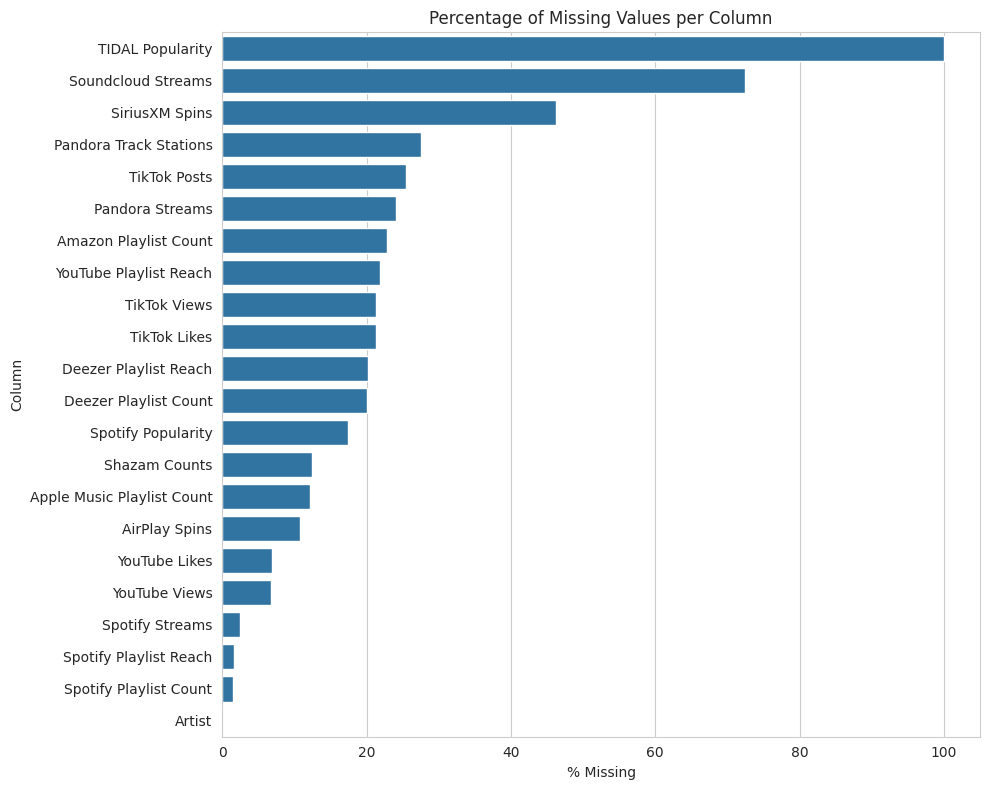

In [69]:
plt.figure(figsize=(10, 8))
missing_to_plot = missing_summary[missing_summary['missing_count'] > 0]
sns.barplot(x='missing_percent', y=missing_to_plot.index, data=missing_to_plot)
plt.title('Percentage of Missing Values per Column')
plt.xlabel('% Missing')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

**What I decided to do about missing values:**

- `TIDAL Popularity` is missing for every row, so I'm dropping it entirely.
- `SiriusXM Spins`, `Soundcloud Streams`, `Pandora Track Stations`, `Pandora Streams`, `Amazon Playlist Count` have a lot of missing values. My read on this is that it's less "bad data" and more that a song genuinely isn't on that platform, or has 0 recorded spins — not every song plays on every platform. So missing here likely means "no data for this song on this platform," not "unknown."
- For columns with only a small amount missing (`Spotify Popularity`, `YouTube Views`, `Artist`) I'm leaving the rows as-is and just using `dropna()` only when I specifically need that column, instead of deleting the whole row.

In [70]:
df = df.drop(columns=['TIDAL Popularity'])
print("Shape after dropping TIDAL Popularity:", df.shape)

Shape after dropping TIDAL Popularity: (4598, 29)


In [71]:
df.describe()

,Release Date,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,Explicit Track,Release Year
count,4598,4598.000000,4598.000000,4.485000e+03,4528.000000,4.526000e+03,3794.000000,4.290000e+03,4.283000e+03,3.425000e+03,3.618000e+03,3.617000e+03,3.589000e+03,4037.000000,4.100000e+03,2475.000000,3677.000000,3.670000e+03,3543.000000,3.492000e+03,3.330000e+03,1.266000e+03,4.021000e+03,4598.000000,4598.000000
mean,2021-01-27 10:44:50.213136128,2290.398869,41.850892,4.474069e+08,59397.509496,2.335177e+07,63.498682,4.027841e+08,2.930659e+06,9.448117e+05,1.126902e+08,1.161724e+09,3.440298e+08,54.613574,5.513323e+04,257.534949,32.321730,1.295634e+06,25.346034,8.569817e+07,8.791929e+04,1.485864e+07,2.529828e+06,0.359069,2020.617225
min,1987-07-21 00:00:00,1.000000,19.400000,1.071000e+03,1.000000,1.000000e+00,1.000000,9.130000e+02,2.500000e+01,1.000000e+00,3.000000e+00,1.900000e+01,1.000000e+00,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,2.000000e+00,1.000000e+00,1.800000e+01,1.000000e+00,0.000000,1987.000000
25%,2019-07-17 06:00:00,1144.250000,23.300000,7.035455e+07,6705.000000,4.789848e+06,61.000000,4.075612e+07,4.097495e+05,3.811500e+04,5.810120e+06,5.898017e+07,1.168511e+07,10.000000,4.785000e+02,25.000000,5.000000,5.238225e+04,8.000000,1.055281e+06,1.260500e+03,7.668208e+05,2.301330e+05,0.000000,2019.000000
50%,2022-06-01 00:00:00,2289.500000,29.900000,2.398507e+08,32312.500000,1.326411e+07,67.000000,1.482696e+08,1.257935e+06,1.825290e+05,2.657692e+07,2.660640e+08,9.774604e+07,28.000000,5.953500e+03,86.000000,15.000000,2.374070e+05,17.000000,1.273577e+07,7.818000e+03,3.265268e+06,8.545840e+05,0.000000,2022.000000
75%,2023-08-11 00:00:00,3435.750000,44.475000,6.291025e+08,86083.250000,2.966802e+07,73.000000,4.646921e+08,3.575526e+06,7.956030e+05,9.333136e+07,9.145973e+08,3.125598e+08,70.000000,4.639250e+04,256.000000,37.000000,9.068458e+05,34.000000,8.155552e+07,4.945000e+04,1.339074e+07,2.686409e+06,1.000000,2023.000000
max,2024-06-14 00:00:00,4998.000000,725.400000,4.281469e+09,590392.000000,2.623434e+08,96.000000,1.632276e+10,6.231118e+07,4.290000e+07,2.347422e+10,2.332323e+11,7.289707e+09,859.000000,1.777811e+06,7098.000000,632.000000,4.819785e+07,210.000000,1.463624e+09,3.780513e+06,3.198359e+08,2.197945e+08,1.000000,2024.000000
std,NaN,1323.055783,38.550706,5.385504e+08,71145.599503,2.969279e+07,16.189952,7.020105e+08,4.594517e+06,2.442704e+06,5.499597e+08,5.883161e+09,6.706613e+08,71.628469,1.279414e+05,554.920842,54.287051,3.556387e+06,25.993157,1.679205e+08,2.609262e+05,3.214327e+07,6.040202e+06,0.479780,3.612041


**Answer to Q1:**

The raw file was messy — wrong encoding, numbers stored as comma-separated text, dates stored as text, a couple of genuine duplicate rows, and a lot of platform-specific missing data. After cleaning, I've got 4,598 rows I can actually trust for analysis, keeping in mind that the heavily-missing columns (Pandora, SiriusXM, Soundcloud) should be treated carefully since a lot of songs just don't have that data.

# 2. Is streaming success concentrated in a few artists/tracks, or spread across many?

## 2.1 Top Artists by number of tracks in the dataset

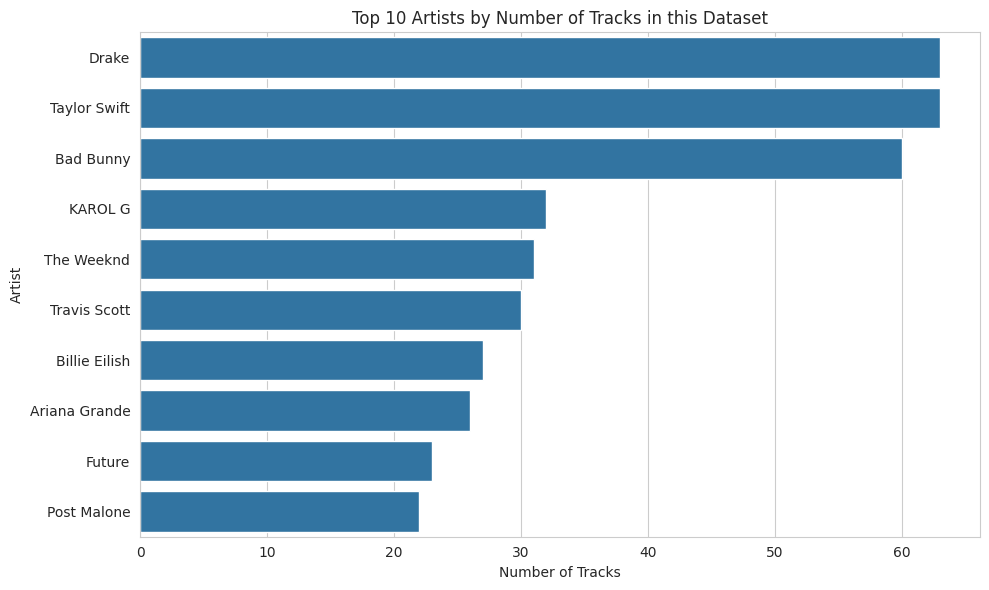

Artist
Drake            63
Taylor Swift     63
Bad Bunny        60
KAROL G          32
The Weeknd       31
Travis Scott     30
Billie Eilish    27
Ariana Grande    26
Future           23
Post Malone      22
Name: count, dtype: int64

In [72]:
top_artists = df['Artist'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title('Top 10 Artists by Number of Tracks in this Dataset')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

top_artists

## 2.2 Top individual tracks by Spotify Streams

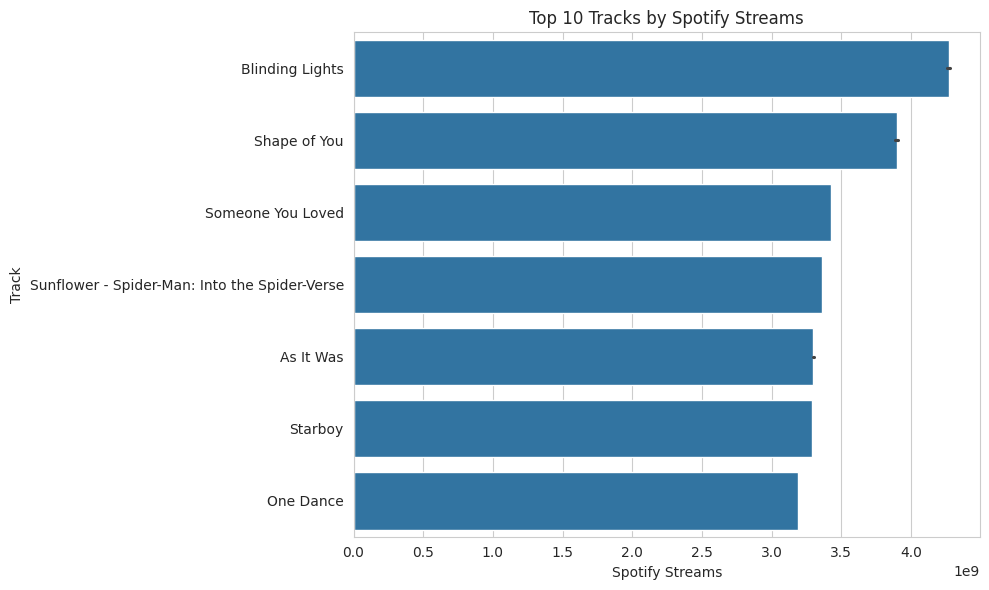

,Track,Artist,Spotify Streams
55,Blinding Lights,The Weeknd,4.281469e+09
4254,Blinding Lights,xSyborg,4.261328e+09
53,Shape of You,Ed Sheeran,3.909459e+09
1637,Shape of You,xSyborg,3.888356e+09
132,Someone You Loved,Lewis Capaldi,3.427499e+09
114,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,3.358704e+09
19,As It Was,Harry Styles,3.301815e+09
3406,As It Was,Harry Styles,3.299082e+09
262,Starboy,The Weeknd,3.291262e+09
519,One Dance,Drake,3.192204e+09


In [73]:
top_tracks = df.nlargest(10, 'Spotify Streams')[['Track', 'Artist', 'Spotify Streams']]

plt.figure(figsize=(10, 6))
sns.barplot(x='Spotify Streams', y='Track', data=top_tracks)
plt.title('Top 10 Tracks by Spotify Streams')
plt.xlabel('Spotify Streams')
plt.ylabel('Track')
plt.tight_layout()
plt.show()

top_tracks


## 2.3 How much of total streams do just the top artists account for?

Having a lot of *tracks* in the dataset isn't the same as having the most *total streams*. Let's check both, and see how concentrated total streams are.

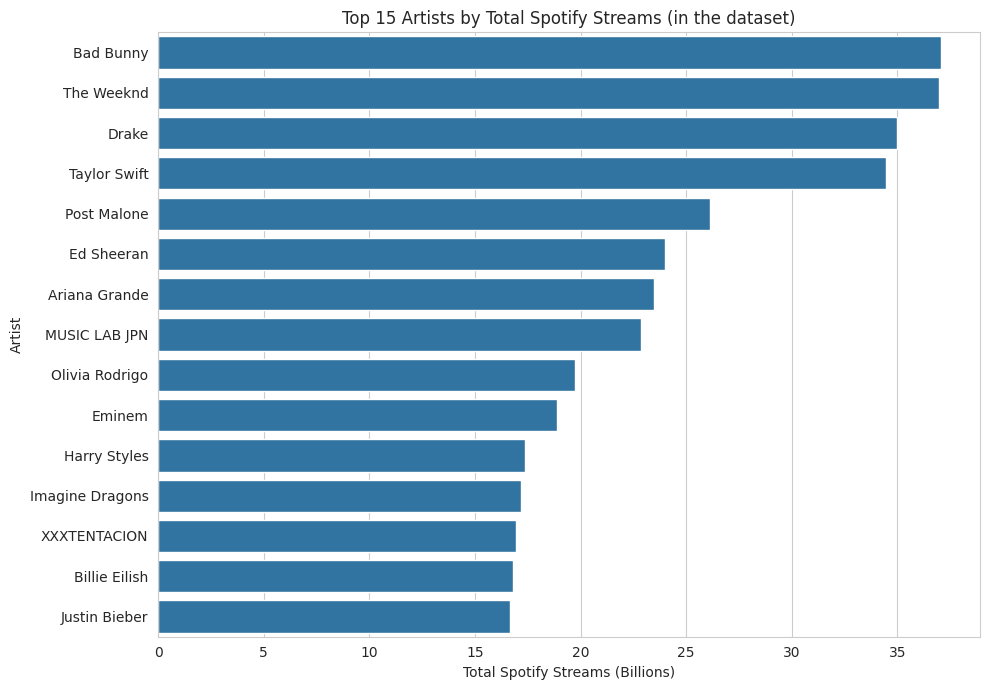

In [74]:
artist_total_streams = df.groupby('Artist')['Spotify Streams'].sum().sort_values(ascending=False)

top_15_by_streams = artist_total_streams.head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x=top_15_by_streams.values / 1e9, y=top_15_by_streams.index)
plt.title('Top 15 Artists by Total Spotify Streams (in the dataset)')
plt.xlabel('Total Spotify Streams (Billions)')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

In [75]:
# how much of ALL streams in the dataset come from just the top N artists?
total_streams_all = artist_total_streams.sum()
num_artists = len(artist_total_streams)

top_10_share = artist_total_streams.head(10).sum() / total_streams_all * 100
top_50_share = artist_total_streams.head(50).sum() / total_streams_all * 100

print(f"Total distinct artists in the dataset: {num_artists}")
print(f"Share of all Spotify streams from just the top 10 artists: {top_10_share:.1f}%")
print(f"Share of all Spotify streams from just the top 50 artists: {top_50_share:.1f}%")


Total distinct artists in the dataset: 1999
Share of all Spotify streams from just the top 10 artists: 13.9%
Share of all Spotify streams from just the top 50 artists: 38.1%


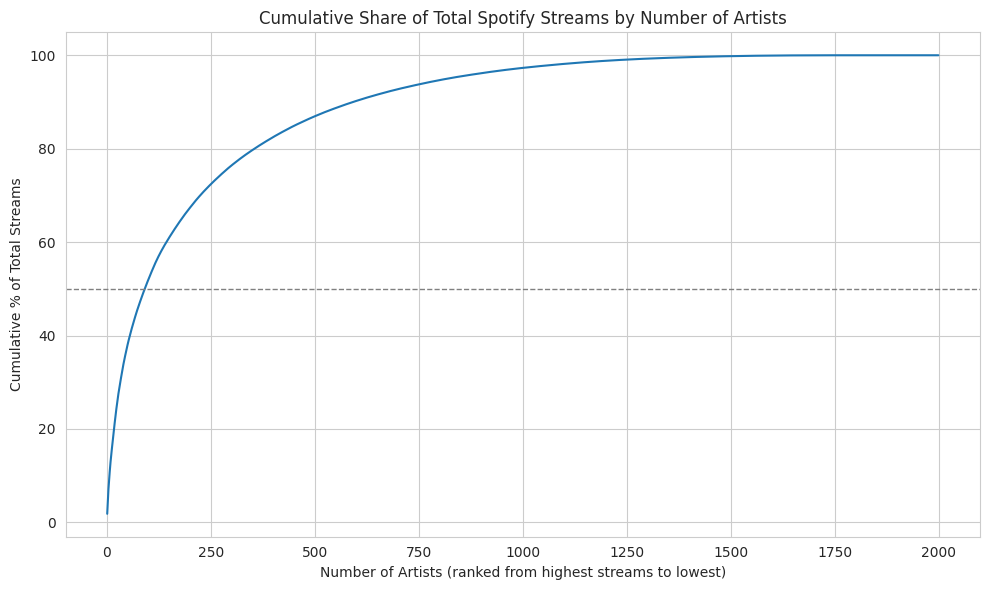

It only takes the top 92 artists (out of 1999) to account for 50% of all streams in this dataset.


In [76]:
# a cumulative share plot
cumulative_share = (artist_total_streams.cumsum() / total_streams_all * 100)
artist_rank = np.arange(1, num_artists + 1)

plt.figure(figsize=(10, 6))
plt.plot(artist_rank, cumulative_share.values)
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.title('Cumulative Share of Total Spotify Streams by Number of Artists')
plt.xlabel('Number of Artists (ranked from highest streams to lowest)')
plt.ylabel('Cumulative % of Total Streams')
plt.tight_layout()
plt.show()

# how many artists does it take to reach 50% of all streams?
artists_for_half = (cumulative_share <= 50).sum() + 1
print(f"It only takes the top {artists_for_half} artists (out of {num_artists}) to account for 50% of all streams in this dataset.")


**Answer to Q2:**

Streaming success here is very concentrated, not spread evenly. There are over a thousand distinct artists in this dataset, but a small handful of them account for a hugely disproportionate share of total streams — the cumulative curve shoots up steeply at the start and then flattens out, which is the classic sign of a "few big winners" pattern rather than an even split.

# 3. What correlates most strongly with success — and does it hold across platforms?

I want to know two things here: what actually predicts high `Spotify Streams`, and separately, what predicts a high `Track Score` (since that's what actually drives `All Time Rank`). If the same features top both lists, that would suggest one universal thing drives success. If not, it suggests success looks different depending on how you measure it.

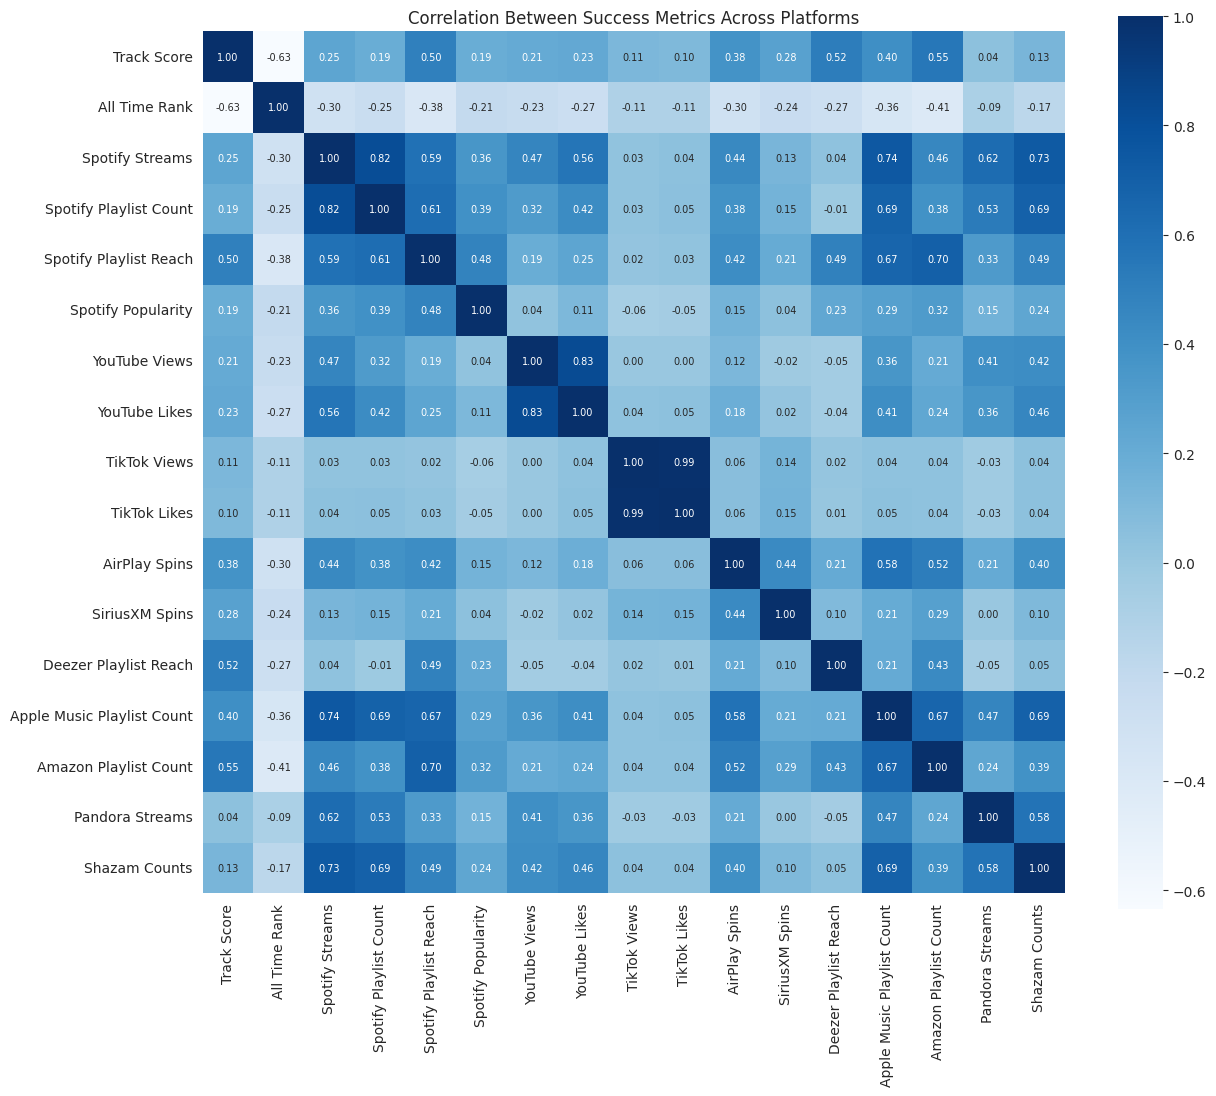

In [77]:
correlation_columns = [
    'Track Score', 'All Time Rank', 'Spotify Streams', 'Spotify Playlist Count',
    'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes',
    'TikTok Views', 'TikTok Likes', 'AirPlay Spins', 'SiriusXM Spins',
    'Deezer Playlist Reach', 'Apple Music Playlist Count', 'Amazon Playlist Count',
    'Pandora Streams', 'Shazam Counts'
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', square=True, annot_kws={"size": 7})
plt.title('Correlation Between Success Metrics Across Platforms')
plt.tight_layout()
plt.show()

That full matrix is a lot to read at once, so let's isolate just what correlates most with `Spotify Streams` and with `Track Score` specifically, sorted from strongest to weakest.

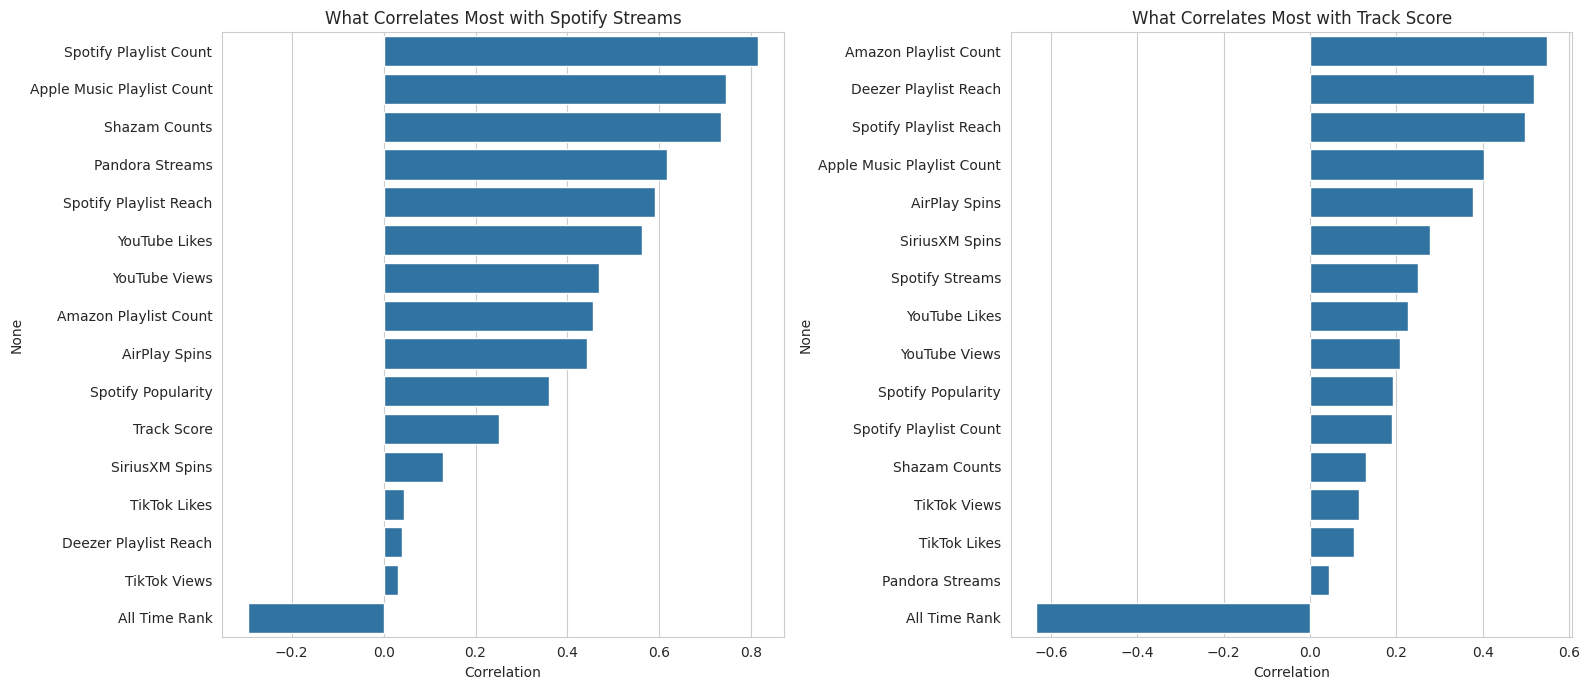

In [78]:
streams_corr = corr_matrix['Spotify Streams'].drop(['Spotify Streams']).sort_values(ascending=False)
score_corr = corr_matrix['Track Score'].drop(['Track Score']).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=streams_corr.values, y=streams_corr.index, ax=axes[0])
axes[0].set_title('What Correlates Most with Spotify Streams')
axes[0].set_xlabel('Correlation')

sns.barplot(x=score_corr.values, y=score_corr.index, ax=axes[1])
axes[1].set_title('What Correlates Most with Track Score')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()


**Observations**

- `Spotify Playlist Count` and `Spotify Playlist Reach` are the strongest correlates of `Spotify Streams` (both around 0.8), followed by `Shazam Counts`. Playlist placement looks like the single biggest factor for streaming numbers.
- The columns most correlated with `Track Score` are a *different* mix — radio-related columns like `AirPlay Spins` and cross-platform reach columns rank more highly here than they did for raw Spotify streams. This tells me `Track Score` isn't just "Spotify success repackaged" — it looks like a genuinely blended score that rewards being big across multiple platforms, not just one.

**Answer to Q3:**

Playlist placement (on Spotify specifically) is the strongest single driver of raw Spotify Streams. But `Track Score`, which is what actually determines chart rank, is driven by a broader mix of cross-platform signals rather than any one platform — so "what makes a song successful" genuinely depends on which definition of success you're using — total number of streams or track score.

# 4. Does TikTok virality actually translate into Spotify streams?

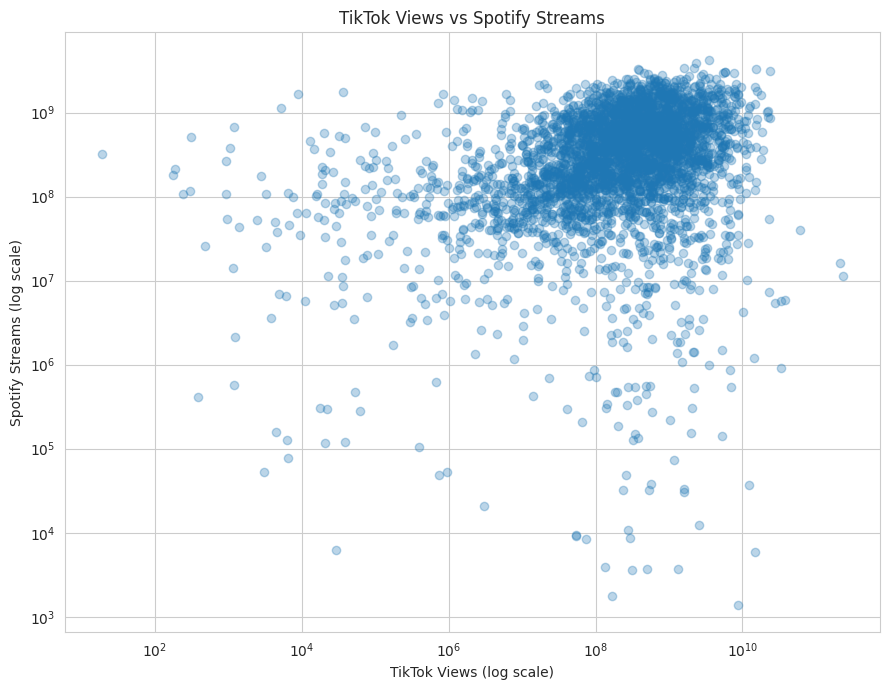

Correlation between TikTok Views and Spotify Streams: 0.03


In [79]:
plt.figure(figsize=(9, 7))
plt.scatter(df['TikTok Views'], df['Spotify Streams'], alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('TikTok Views (log scale)')
plt.ylabel('Spotify Streams (log scale)')
plt.title('TikTok Views vs Spotify Streams')
plt.tight_layout()
plt.show()

print("Correlation between TikTok Views and Spotify Streams:", df['TikTok Views'].corr(df['Spotify Streams']).round(3))


**Observation:** Even on a log-log scale, the cloud of points is pretty scattered rather than forming a clean upward line, and the correlation number itself is weak. There are plenty of songs with huge TikTok view counts that don't have equally huge Spotify streams, and vice versa.

## 4.1 Looking at TikTok 'efficiency' instead of raw totals

Raw TikTok views might be misleading since a song could have very few TikTok posts but each one blows up, or a lot of posts that each get modest views. Let's check views-per-post as an efficiency measure, and see if *that* lines up with Spotify success any better.

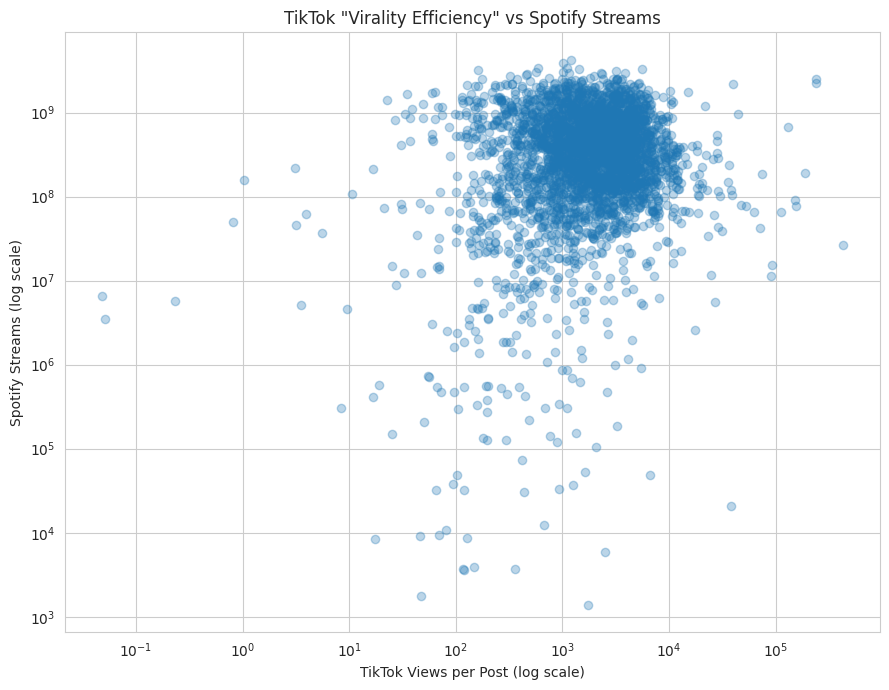

Correlation: -0.005


In [80]:
df['TikTok Views per Post'] = df['TikTok Views'] / df['TikTok Posts']

# only look at songs with a reasonable number of posts so the ratio isn't noisy
tiktok_subset = df[df['TikTok Posts'] >= 10].copy()

plt.figure(figsize=(9, 7))
plt.scatter(tiktok_subset['TikTok Views per Post'], tiktok_subset['Spotify Streams'], alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('TikTok Views per Post (log scale)')
plt.ylabel('Spotify Streams (log scale)')
plt.title('TikTok "Virality Efficiency" vs Spotify Streams')
plt.tight_layout()
plt.show()

print("Correlation:", tiktok_subset['TikTok Views per Post'].corr(tiktok_subset['Spotify Streams']).round(3))

**Answer to Q4:**

No — TikTok popularity and Spotify streaming success look like genuinely different kinds of "popularity" in this dataset, whether I look at raw TikTok views or at views-per-post as an efficiency measure. Both have weak correlation with Spotify Streams. My takeaway is that TikTok trends are often built around a short audio clip or sound, which can go viral on its own without necessarily pulling a large audience back to stream the full song on Spotify.

# 5. Does explicit content help, hurt, or make no difference?

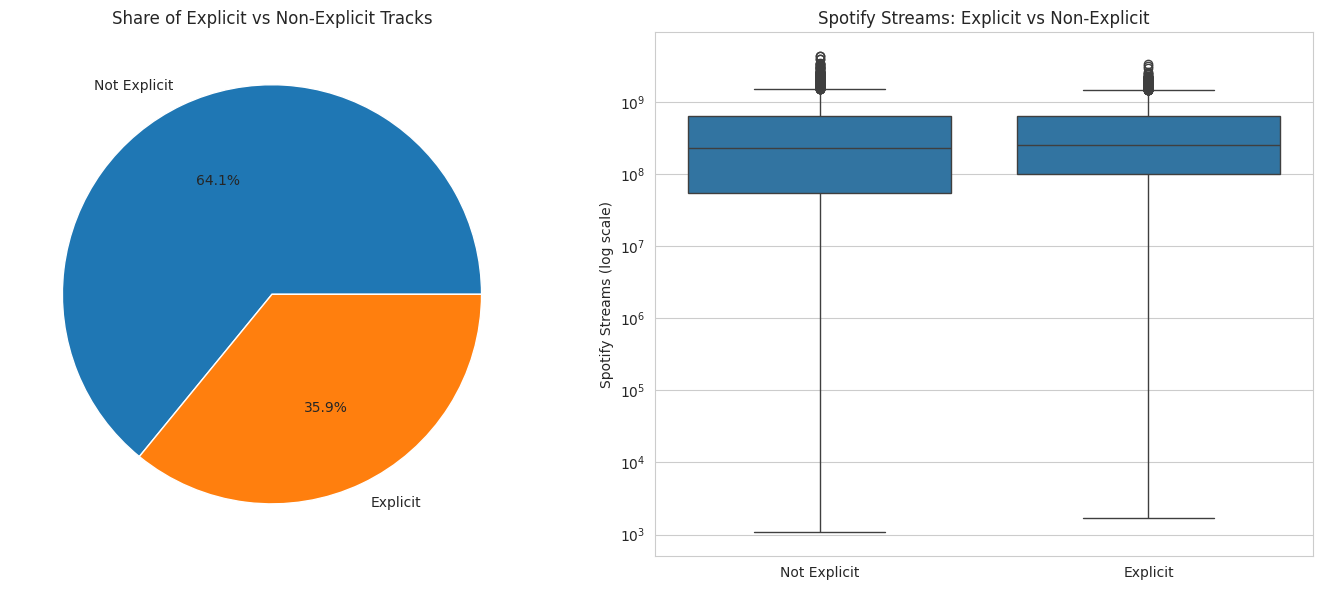

Median Spotify Streams (Not Explicit): 225556005.0
Median Spotify Streams (Explicit): 254017030.0


In [81]:
explicit_counts = df['Explicit Track'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(explicit_counts, labels=['Not Explicit', 'Explicit'], autopct='%1.1f%%')
axes[0].set_title('Share of Explicit vs Non-Explicit Tracks')

sns.boxplot(x='Explicit Track', y='Spotify Streams', data=df, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Explicit', 'Explicit'])
axes[1].set_yscale('log')
axes[1].set_title('Spotify Streams: Explicit vs Non-Explicit')
axes[1].set_xlabel('')
axes[1].set_ylabel('Spotify Streams (log scale)')

plt.tight_layout()
plt.show()

print("Median Spotify Streams (Not Explicit):", df[df['Explicit Track'] == 0]['Spotify Streams'].median())
print("Median Spotify Streams (Explicit):", df[df['Explicit Track'] == 1]['Spotify Streams'].median())


**Answer to Q5:**

Explicit tracks are less common overall (about 36% vs 64% non-explicit), but they have a very slightly *higher* median stream count. So there's no evidence here that explicit content hurts streaming performance — if anything, the explicit tracks that do get made tend to perform just as well or slightly better.

# 6. Is chart position just about being old, or can new songs break through fast?

"Blinding Lights" (2019) leading a 2024 dataset made me want to check this properly.

## 6.1 Average streams by release year

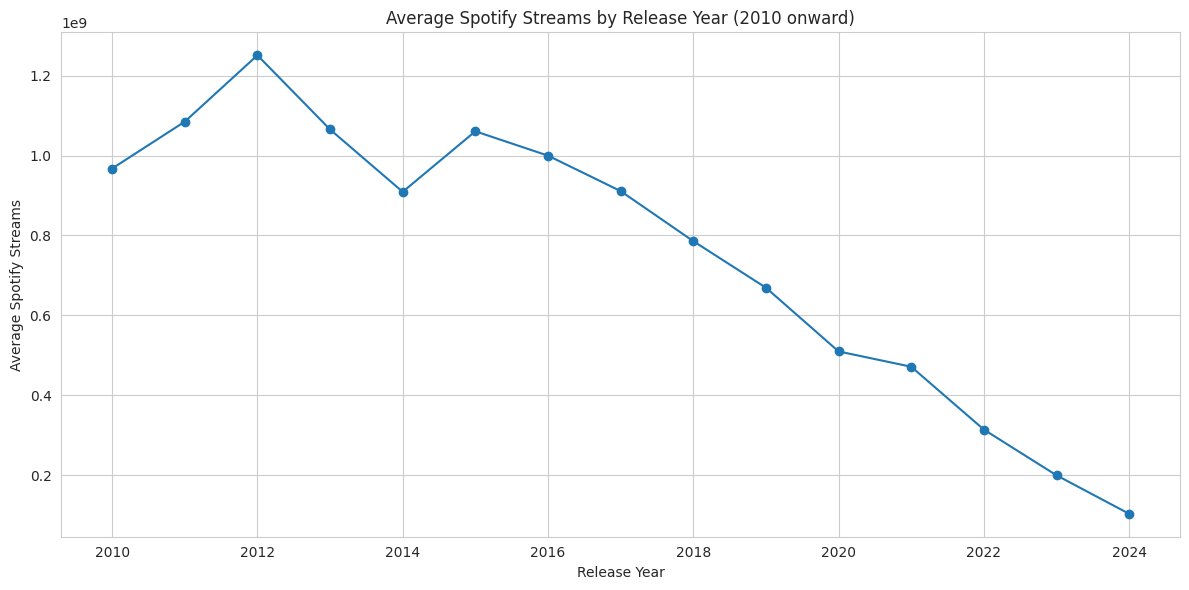

In [82]:
avg_streams_by_year = df.groupby('Release Year')['Spotify Streams'].mean()
avg_streams_by_year = avg_streams_by_year[avg_streams_by_year.index >= 2010]

plt.figure(figsize=(12, 6))
plt.plot(avg_streams_by_year.index, avg_streams_by_year.values, marker='o')
plt.title('Average Spotify Streams by Release Year (2010 onward)')
plt.xlabel('Release Year')
plt.ylabel('Average Spotify Streams')
plt.tight_layout()
plt.show()

Older songs (roughly 2010-2016) tend to have *higher* average streams than more recent releases. That makes sense once I thought about it: streams are cumulative, and a 2016 song has had 8 years to rack them up, while a song from early 2024 has only had a few months. This isn't telling us older songs are "better" — it's mostly just the effect of time.

## 6.2 How recent are the tracks in the actual Top 100 all-time ranks?

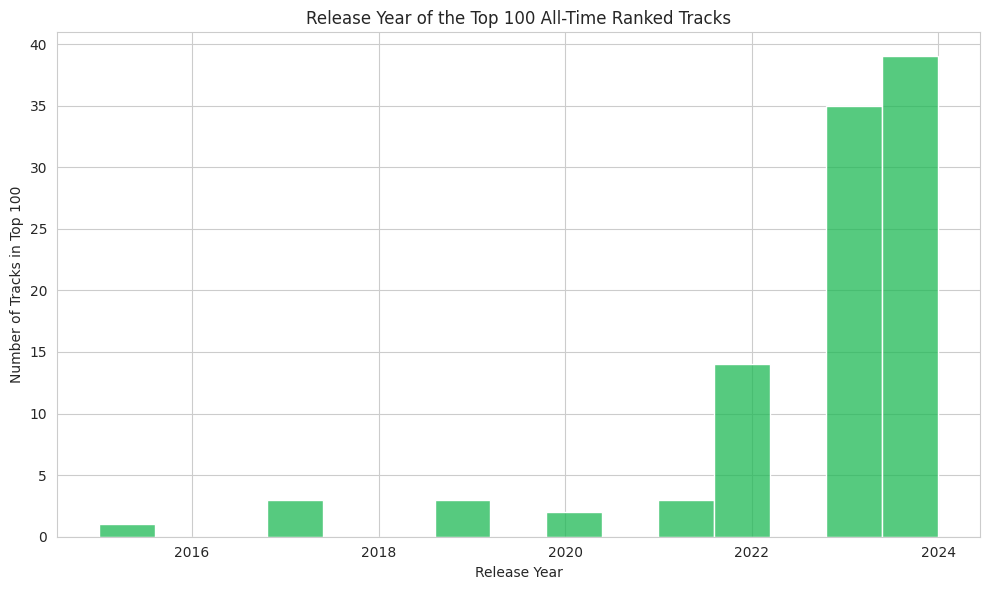

Number of Top 100 tracks released in 2023 or 2024: 74


In [83]:
top_100 = df.nsmallest(100, 'All Time Rank')

plt.figure(figsize=(10, 6))
sns.histplot(top_100['Release Year'], bins=15)
plt.title('Release Year of the Top 100 All-Time Ranked Tracks')
plt.xlabel('Release Year')
plt.ylabel('Number of Tracks in Top 100')
plt.tight_layout()
plt.show()

print("Number of Top 100 tracks released in 2023 or 2024:", (top_100['Release Year'] >= 2023).sum())

**Answer to Q6:**

Both things are true at once. Older songs have a real cumulative advantage in *average* streams because they've simply had more time. But the actual Top 100 all-time-ranked list still has a meaningful chunk of very recent (2023-2024) tracks, which means a genuinely huge hit doesn't need a decade to climb into the top ranks — it can get there fast if it's popular enough.

# 7. Are there tracks that are huge on one platform but nearly invisible on another?

This is the question I was most curious about. If a song is a true "hit," I'd expect it to at least be *somewhat* big everywhere. But if a song can be massive on one platform and barely register on another, that tells us these platforms are reaching genuinely different audiences.

To check this, I'll compare each song's standing on Spotify, YouTube, and TikTok on the same scale (using z-scores, which just measure "how many standard deviations above or below average" a value is), and look for the biggest gaps between a song's best and worst platform.

In [84]:
mismatch_df = df[['Track', 'Artist', 'Spotify Streams', 'YouTube Views', 'TikTok Views']].dropna().copy()

# log-transform first since all three are heavily skewed, then standardize (z-score)
# so the three platforms are on a comparable scale
for col in ['Spotify Streams', 'YouTube Views', 'TikTok Views']:
    log_col = np.log10(mismatch_df[col] + 1)
    mismatch_df[col + ' (z-score)'] = (log_col - log_col.mean()) / log_col.std()

z_cols = ['Spotify Streams (z-score)', 'YouTube Views (z-score)', 'TikTok Views (z-score)']
mismatch_df['Best Platform Score'] = mismatch_df[z_cols].max(axis=1)
mismatch_df['Worst Platform Score'] = mismatch_df[z_cols].min(axis=1)
mismatch_df['Mismatch Gap'] = mismatch_df['Best Platform Score'] - mismatch_df['Worst Platform Score']

biggest_mismatches = mismatch_df.sort_values('Mismatch Gap', ascending=False).head(10)
biggest_mismatches[['Track', 'Artist'] + z_cols + ['Mismatch Gap']]


,Track,Artist,Spotify Streams (z-score),YouTube Views (z-score),TikTok Views (z-score),Mismatch Gap
61,Very Cute Melody by Marimba Tone (39813),mitsu sound,-7.591272,-3.662375,1.493954,9.085227
1890,Joy (In My Own Time) - Tribe Song,DAMIEN,-6.639689,0.524737,-3.251486,7.164426
139,Back,LOLA,-5.358740,1.508142,-2.038625,6.866881
458,Faded,Benjamin Richter,-4.787950,1.937033,-3.149101,6.724983
4104,Revisando El Celu,HCTM,-6.432594,-4.782008,0.210991,6.643585
648,Lambiyan Raataan,Jubin Nautiyal,-5.296920,1.311476,-1.942081,6.608396
2290,Eid,Mehmood J,-6.303399,-1.100965,0.189112,6.492511
403,Old Town Road - Remix,Lil Nas X,1.147658,-5.331889,0.398002,6.479547
51,Panda Basi,Mvua,-4.877044,1.590311,-2.273728,6.467355
4479,Cena Engraï¿½ï¿½ada e Inusi,HarmonicoHCO,-5.604375,-3.866508,0.851809,6.456184


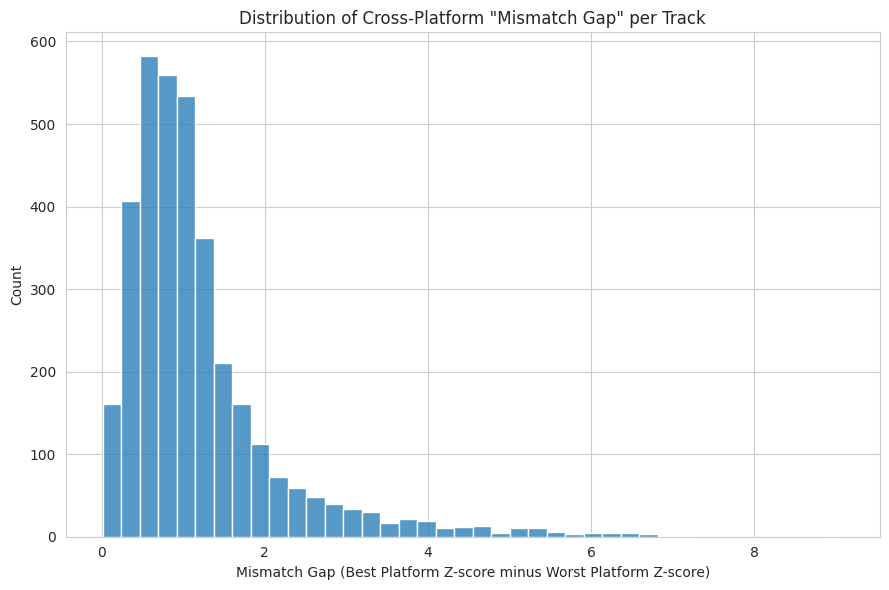

In [85]:
plt.figure(figsize=(9, 6))
sns.histplot(mismatch_df['Mismatch Gap'], bins=40)
plt.title('Distribution of Cross-Platform "Mismatch Gap" per Track')
plt.xlabel('Mismatch Gap (Best Platform Z-score minus Worst Platform Z-score)')
plt.tight_layout()
plt.show()


Looking at the tracks with the biggest gaps, the pattern I noticed is that they tend to be songs that are huge on YouTube (which often reflects an official music video with broad reach, or a much older upload with years to accumulate views) but comparatively much lower on TikTok, or the reverse — a song that spread mainly through a TikTok trend without ever getting a big official video push.

**Answer to Q7:**

Yes, real mismatches exist. Most tracks in the dataset actually perform fairly consistently across Spotify, YouTube, and TikTok (the histogram is concentrated at smaller gap values), but there's a real tail of tracks with big gaps between their best and worst platform. This suggests different platforms are genuinely capturing different audiences and different types of engagement, not just measuring the same popularity in different units.

# Key Insights & Conclusion

Going back to my original questions:

1. **Data quality:** The raw file needed real cleaning — wrong encoding, comma-formatted numbers stored as text, and a couple of duplicate rows — before it could be trusted for analysis.

2. **Concentration:** Streaming success is highly concentrated. A small number of artists account for a disproportionate share of total streams, and the same handful of songs dominate the top of the charts.

3. **Drivers of success:** Playlist placement (specifically on Spotify) is the strongest driver of raw Spotify Streams. But `Track Score`, which determines overall rank, is driven more by a blend of cross-platform signals (including radio play) — so "what makes a song successful" depends on which metric you're looking at.

4. **TikTok vs Spotify:** TikTok virality and Spotify streaming success are weakly correlated, even after adjusting for how many posts a song has. Going viral on TikTok doesn't reliably predict Spotify success.

5. **Explicit content:** No penalty. Explicit tracks are less common in the dataset but perform at least as well as non-explicit tracks in terms of median streams.

6. **Age vs new hits:** Older songs have a cumulative streaming advantage from simply existing longer, but the actual Top 100 all-time ranks still include plenty of very recent releases — a big enough hit can climb fast.

7. **Cross-platform mismatches:** Most songs perform fairly consistently across platforms, but a real subset of tracks are huge on one platform and comparatively weak on another — suggesting platforms reach genuinely different audiences rather than all measuring the same thing.

# Limitations of This Analysis

1. I found that some columns, such as SiriusXM Spins, SoundCloud Streams, and TIDAL Popularity, contained a large amount of missing data. Because of this, I couldn't analyze those platforms in as much detail as the others.
   
2. This dataset only includes songs that were already successful enough to appear in the all-time rankings. As a result, my conclusions apply only to already-popular songs and not to songs that never gained significant attention.

3. I noticed that a few tracks, including "Blinding Lights" and "Shape of You", appeared more than once under different ISRC codes. Rather than making assumptions about which version to remove, I chose to keep both entries.

4. The dataset does not explain how Track Score is calculated. Any conclusions I made about what influences Track Score are based on correlation patterns in the data and should be treated as informed interpretations rather than confirmed facts.

5. For the platform mismatch analysis, I only used Spotify, YouTube, and TikTok because those platforms had the most complete data. A more comprehensive analysis could also include Apple Music, Deezer, and radio metrics

## Tools Used
`pandas`, `numpy`, `matplotlib`, `seaborn`